In [ ]:
from pathlib import Path

from google.colab import drive

MOUNT_PATH = Path("/content/drive")
DATA_PATH = MOUNT_PATH / "MyDrive" / "data-conference"
drive.mount(str(MOUNT_PATH), readonly=True)

Mounted at /content/drive


# Setup

In [ ]:
from datetime import UTC, datetime

# NOTE: For `CUTOFF`, the idea was to ignore recent PRs that were still open and
# had few reviews/comments. It's unrelated to coding agent release dates.
APPLY_CUTOFF = False
CUTOFF = datetime(2026, 5, 1, tzinfo=UTC)  # 00:00 UTC on May 1, 2026
DEDUPLICATE_BY_NODE_ID = False

In [ ]:
import json

repos = []
# Sort entries to ensure consistency between runs.
for path in sorted(DATA_PATH.iterdir()):
    if path.suffix != ".json":
        continue
    with path.open("r", encoding="utf-8", newline="\n") as file:
        repos.append(json.load(file)["repository"])

In [ ]:
# Collect PRs from all repositories into one data frame.
import pandas as pd

if True:
    # Avoid `record_path` and `meta` to improve performance:
    # https://github.com/pandas-dev/pandas/blob/v2.2.2/pandas/io/json/_normalize.py#L447-L457
    all_pr_df = (
        pd.concat(
            {
                repo["nameWithOwner"]: pd.json_normalize(repo["pullRequests"]["nodes"])
                for repo in repos
            },
            names=["nameWithOwner"],
        )
        .reset_index(level="nameWithOwner")
        .reset_index(drop=True)
    )
else:
    all_pr_df = pd.json_normalize(
        repos, record_path=["pullRequests", "nodes"], meta="nameWithOwner"
    )

In [ ]:
# Change column names and data types.
import re

from pandas import CategoricalDtype


# Convert from `camelCase` to `snake_case`.
def convert_case(name: str) -> str:
    words = re.split("(?<=[^A-Z])(?=[A-Z])|(?=[A-Z][^A-Z])", name)
    if not words[0]:
        # words = words[1:]
        pass
    return "_".join(words).lower()


# https://docs.github.com/en/graphql/reference/pulls#enum-pullrequeststate
pr_state_type = CategoricalDtype(["CLOSED", "MERGED", "OPEN"])

all_pr_df = (
    all_pr_df.rename(columns=convert_case)
    .rename(columns={"name_with_owner": "repo_full_name"})
    .astype({"state": pr_state_type})
)
assert all_pr_df["state"].notna().all()

all_pr_df["closed_at"] = pd.to_datetime(all_pr_df["closed_at"], format="ISO8601")
all_pr_df["created_at"] = pd.to_datetime(all_pr_df["created_at"], format="ISO8601")
all_pr_df["merged_at"] = pd.to_datetime(all_pr_df["merged_at"], format="ISO8601")

In [ ]:
if DEDUPLICATE_BY_NODE_ID:
    # Use node IDs as indices.
    all_pr_df = all_pr_df.set_index("id", verify_integrity=False)

In [ ]:
# Deduplicate PRs by their indices.
# This has no effect when `DEDUPLICATE_BY_NODE_ID` is `False`.
from IPython.display import display

# NOTE(Daniel): I merged the `.jsonl` files in order of ascending collection date.
# Therefore, the last PRs are the most up to date.
pr_duplicated = all_pr_df.index.to_series().duplicated(keep="last")
pr_duplicated_counts = pr_duplicated.groupby(all_pr_df["repo_full_name"]).sum()
print(f"Total duplicated PRs: {pr_duplicated_counts.sum():,}")
display(pr_duplicated_counts)

all_pr_df = all_pr_df[~pr_duplicated]
assert all_pr_df.index.is_unique

Total duplicated PRs: 0


,0
repo_full_name,
Genymobile/scrcpy,0
Significant-Gravitas/AutoGPT,0
TheAlgorithms/Python,0
ant-design/ant-design,0
langchain-ai/langchain,0
microsoft/PowerToys,0
microsoft/TypeScript,0
microsoft/vscode,0
open-webui/open-webui,0


In [ ]:
# https://docs.github.com/en/graphql/reference/pulls#union-pullrequesttimelineitems
pr_timeline_item_type = CategoricalDtype(
    [
        "ClosedEvent",
        "HeadRefForcePushedEvent",
        "IssueComment",
        "MergedEvent",
        "PullRequestCommit",
        "PullRequestReview",
        "ReopenedEvent",
    ]
)

# https://docs.github.com/en/graphql/reference/issues#enum-issuestatereason
issue_state_reason_type = CategoricalDtype(
    ["COMPLETED", "DUPLICATE", "NOT_PLANNED", "REOPENED"]
)

In [ ]:
# Flatten timeline items into a separate data frame.
all_pr_df["has_next_page"] = all_pr_df.pop("timeline_items.page_info.has_next_page")
timeline_items = all_pr_df.pop("timeline_items.nodes").explode()

all_timeline_item_df = (
    pd.json_normalize(timeline_items.to_list())
    .rename(columns=convert_case)
    .rename(columns={"__typename": "typename"})
    .astype(
        {"typename": pr_timeline_item_type, "state_reason": issue_state_reason_type}
    )
)
assert all_timeline_item_df.index.is_unique
assert all_timeline_item_df["typename"].notna().all()

# TODO: Flatten `commit.authors.nodes`.
for column in [
    "commit.authored_date",
    "commit.committed_date",
    "created_at",
    "submitted_at",
]:
    all_timeline_item_df[column] = pd.to_datetime(
        all_timeline_item_df[column], format="ISO8601"
    )

# Preserve the "exploded" index as a column mapping timeline items to PRs.
all_timeline_item_df = pd.concat(
    [
        timeline_items.index.to_series(
            index=all_timeline_item_df.index,
            name="pr_index",
        ),
        all_timeline_item_df,
    ],
    axis="columns",
)

In [ ]:
if APPLY_CUTOFF:
    # Keep PRs created before the cutoff.
    all_pr_mask = all_pr_df["created_at"] < CUTOFF
    print(f"Removing {(~all_pr_mask).sum():,} PRs...")
    all_pr_df = all_pr_df[all_pr_mask]

    # Keep timeline items belonging to the remaining PRs.
    all_timeline_item_mask = all_timeline_item_df["pr_index"].isin(all_pr_df.index)
    print(f"Removing {(~all_timeline_item_mask).sum():,} timeline items...")
    all_timeline_item_df = all_timeline_item_df[all_timeline_item_mask]

In [ ]:
# Create one PR data frame per repository.
pr_df_map = {
    repo_full_name: pr_df.drop("repo_full_name", axis="columns")
    for (repo_full_name, pr_df) in all_pr_df.groupby("repo_full_name")
}

In [ ]:
# Create one timeline item data frame per repository.
timeline_item_df_map = all_timeline_item_df.join(
    all_pr_df["repo_full_name"], on="pr_index", validate="many_to_one"
).pipe(
    lambda df: {
        repo_full_name: timeline_item_df.drop("repo_full_name", axis="columns")
        for (repo_full_name, timeline_item_df) in df.groupby("repo_full_name")
    }
)

# Notes

## GHTorrent

Georgios Gousios and Diomidis Spinellis [introduced GHTorrent in 2011][1], and Gousios remained as the sole maintainer [until 2021][2]. Unfortunately, the dataset is no longer up-to-date.

You can still read the [FAQ on GitHub][3].

[1]: <https://gousios.org/bibliography/GS12.html>
[2]: <https://gousios.org/research.html#:~:text=From 2011 till 2021>
[3]: <https://github.com/ghtorrent/ghtorrent.org/blob/master/faq.md>

## LLM Agent Email Addresses

I searched on GitHub for commits containing each email address. Based on the number of commits, I listed the email addresses from most common to least common.

**Claude Code (Anthropic):**
1. `noreply@anthropic.com`
2. `svc-devxp-claude@slack-corp.com` ([Example](https://github.com/electron/electron/commit/b93642678))

**Copilot (GitHub):**
1. `223556219+Copilot@users.noreply.github.com` ([CLI](https://github.com/apps/github-copilot-cli))
2. `175728472+Copilot@users.noreply.github.com` ([Code review](https://github.com/apps/copilot-pull-request-reviewer))
3. `198982749+Copilot@users.noreply.github.com` ([Cloud agent](https://github.com/apps/copilot-swe-agent))
4. `github-copilot[bot]@users.noreply.github.com` ([Example](https://github.com/microsoft/TypeAgent/commit/1e37c9c5575550149))
5. `175728472+github-copilot[bot]@users.noreply.github.com` ([Example](https://github.com/OpenRTX/OpenRTX/commit/e78597632))

**Gemini (Google):**
1. `176961590+gemini-code-assist[bot]@users.noreply.github.com`

Also, I found that [Amp](https://ampcode.com/) uses a custom trailer named `Amp-Thread-ID`, which contains a URL pointing to a chat/thread. For example, [one commit](https://github.com/AprilNEA/OpenLogi/commit/0832c06988) on the OpenLogi repository has the following trailer:
```
Amp-Thread-ID: https://ampcode.com/threads/T-01a0330c-8cc9-7399-b94e-8812c1a92c43
```

## LLM Agent Release Dates

Compare against LLM agent tool release dates.
- Claude Code (Anthropic):
  - [February 24, 2025][1]: Research preview
  - [May 22, 2025][2]: Generally available
- Codex (OpenAI):
  - [April 16, 2025][3]: Codex CLI released
  - [May 16, 2025][4]: Codex (Web) research preview
  - [June 3, 2025][4]: Codex (Web) available to ChatGPT Plus users
  - [February 2, 2026][5]: Codex (Web) available to ChatGPT Free and Go users "for a limited time"
- Copilot (GitHub):
  - [February 6, 2025][6]: Agent mode public preview
  - [May 19, 2025][7]: Coding agent public preview
  - [June 24, 2025][8]: Coding agent available to Copilot Business users
  - [June 26, 2025][9]: Coding agent available to Copilot Pro users
    - Copilot Pro is free for teachers and OSS maintainers.

Copilot "agent mode" and the Copilot "coding agent" are separate according to [a GitHub blog post][10]. The PRs in the AIDev dataset come from the coding agent, since agent mode cannot create PRs (AFAIK).

Note that all of these tools are specifically for coding.

[1]: https://www.anthropic.com/news/claude-3-7-sonnet
[2]: https://www.anthropic.com/news/claude-4
[3]: https://openai.com/index/introducing-o3-and-o4-mini/
[4]: https://openai.com/index/introducing-codex/
[5]: https://openai.com/index/introducing-the-codex-app/
[6]: https://github.blog/changelog/2025-02-06-next-edit-suggestions-agent-mode-and-prompts-files-for-github-copilot-in-vs-code-january-release-v0-24/
[7]: https://github.blog/changelog/2025-05-19-github-copilot-coding-agent-in-public-preview/
[8]: https://github.blog/changelog/2025-06-24-github-copilot-coding-agent-is-now-available-for-copilot-business-users/
[9]: https://github.blog/changelog/2025-06-26-github-copilot-coding-agent-is-available-for-copilot-pro-users-in-public-preview/
[10]: https://github.blog/developer-skills/github/less-todo-more-done-the-difference-between-coding-agent-and-agent-mode-in-github-copilot/

# Analysis

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

## Basic

In [ ]:
repo_pr_counts = all_pr_df.groupby("repo_full_name").size()
print(f"Total PRs: {repo_pr_counts.sum():,}")
display(repo_pr_counts)

Total PRs: 192,130


,0
repo_full_name,
Genymobile/scrcpy,656
Significant-Gravitas/AutoGPT,7883
TheAlgorithms/Python,12134
ant-design/ant-design,22113
langchain-ai/langchain,22110
microsoft/PowerToys,7802
microsoft/TypeScript,19139
microsoft/vscode,56207
open-webui/open-webui,7482


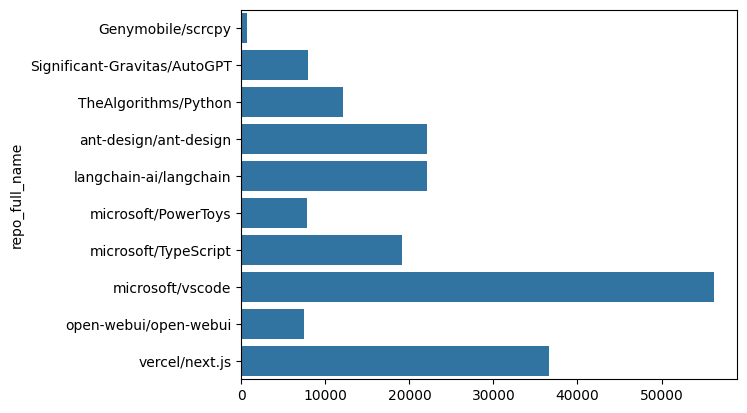

In [ ]:
sns.barplot(repo_pr_counts, orient="h")
plt.show()

I compared these PR counts to the counts displayed when searching for PRs on GitHub.

In [ ]:
pr_df_map["Genymobile/scrcpy"]["created_at"].max()

Timestamp('2026-04-30 13:09:21+0000', tz='UTC')

For example: I collected 656 PRs from `Genymobile/scrcpy`, yet if you search for all PRs created before the cutoff ([`is:pr created:<=2026-04-30T13:09:21Z`](https://github.com/Genymobile/scrcpy/pulls?q=is:pr+created:<=2026-04-30T13:09:21Z)), GitHub displays a total of 650 PRs.

As far as I can tell, the discrepancy is due to deleted/archived PRs as well as PRs created by "ghost" users (users who have deleted their GitHub accounts). Indeed, there are two PRs created by ghost users ([#1783](https://github.com/Genymobile/scrcpy/pull/1783) and [#1799](https://github.com/Genymobile/scrcpy/pull/1799)), and four deleted/archived PRs ([#5929](https://github.com/Genymobile/scrcpy/pull/5929), [#6744](https://github.com/Genymobile/scrcpy/pull/6744), [#6795](https://github.com/Genymobile/scrcpy/pull/6795), and [#6797](https://github.com/Genymobile/scrcpy/pull/6797)).

I know the last four numbers aren't assigned to issues because GitHub returns errors (404) instead of redirects (3XX).

In [ ]:
pr_state_counts = all_pr_df["state"].value_counts()
(pr_state_counts / pr_state_counts.sum() * 100).round(1)

,count
state,
MERGED,72.8
CLOSED,24.8
OPEN,2.5


In [ ]:
repo_pr_state_counts = all_pr_df.value_counts(["repo_full_name", "state"])
repo_pr_state_counts = repo_pr_state_counts.unstack(level="state")
repo_state_counts = repo_pr_state_counts.sum(axis="columns")
repo_pr_state_counts.div(repo_state_counts, axis="index").mul(100).round(1)

state,CLOSED,MERGED,OPEN
repo_full_name,,,
Genymobile/scrcpy,67.2,21.6,11.1
Significant-Gravitas/AutoGPT,43.5,55.0,1.5
TheAlgorithms/Python,68.5,25.3,6.2
ant-design/ant-design,20.7,78.9,0.4
langchain-ai/langchain,24.9,74.4,0.7
microsoft/PowerToys,13.9,84.4,1.7
microsoft/TypeScript,22.2,77.7,0.1
microsoft/vscode,14.3,82.7,3.0
open-webui/open-webui,51.6,47.3,1.1


In [ ]:
all_pr_df["has_next_page"].value_counts()

,count
has_next_page,
False,191091
True,1039


In [ ]:
# Count the number of items per PR, correctly handling PRs that don't have any items.
pr_timeline_item_counts = (
    pd.merge(
        all_pr_df.index.to_series(name="index"),
        all_timeline_item_df["pr_index"],
        how="left",
        left_on="index",
        right_on="pr_index",
        validate="one_to_many",
    )
    .groupby("index", sort=False)["pr_index"]
    .count()
)
pr_timeline_item_counts.describe()

,pr_index
count,192130.000000
mean,9.944756
std,11.635409
min,1.000000
25%,4.000000
50%,6.000000
75%,11.000000
max,100.000000


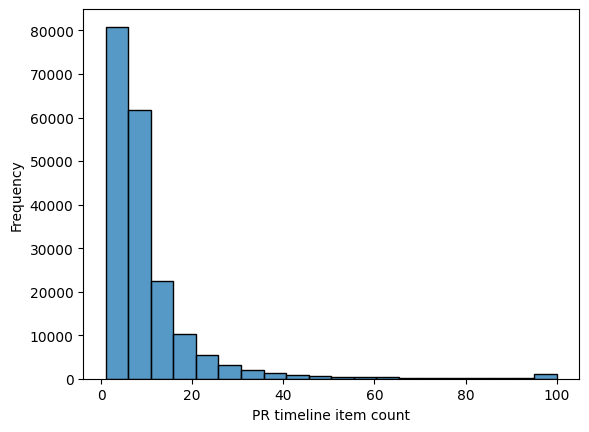

In [ ]:
sns.histplot(pr_timeline_item_counts, bins=20)
plt.xlabel("PR timeline item count")
plt.ylabel("Frequency")
plt.show()

In [ ]:
item_count_type = CategoricalDtype(list(range(0, 101)) + ["101+"], ordered=True)
pr_timeline_item_counts = pr_timeline_item_counts.mask(
    all_pr_df["has_next_page"], "101+"
).astype(item_count_type)
assert pr_timeline_item_counts.notna().all()

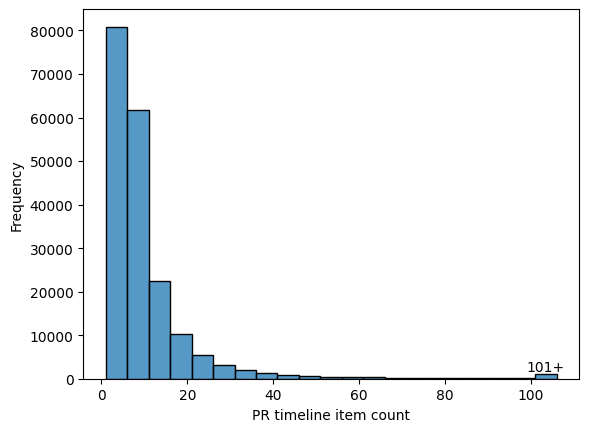

In [ ]:
bin_width = 5
assert pr_timeline_item_counts.min() == 1
bins = list(range(1, len(item_count_type.categories) - 1, bin_width))
bins.append(len(item_count_type.categories) - 1)
bins.append(len(item_count_type.categories) - 1 + bin_width)
# bins.append(len(item_count_type.categories) - 1 + (bins[1] - bins[0]))
axes = sns.histplot(pr_timeline_item_counts.cat.codes, bins=bins)
bar_count = len(bins) - 1
plt.bar_label(axes.containers[0], [""] * (bar_count - 1) + ["101+"])
ticks = range(0, len(item_count_type.categories), 20)
plt.xticks(ticks, item_count_type.categories[ticks])  # type: ignore
plt.xlabel("PR timeline item count")
plt.ylabel("Frequency")
plt.show()

In [ ]:
commit_author_counts = all_timeline_item_df["commit.authors.nodes"].dropna().map(len)
commit_author_counts.value_counts().sort_index()

,count
commit.authors.nodes,
1,748444
2,28123
3,1905
4,378
5,104
6,39
7,12
8,14
9,10


Only a small number of commits have 10 or more (co-)authors.

In [ ]:
all_pr_df["additions"].describe()

,additions
count,1.921300e+05
mean,1.124548e+03
std,4.000953e+04
min,0.000000e+00
25%,4.000000e+00
50%,2.200000e+01
75%,1.030000e+02
max,8.574328e+06


In [ ]:
all_pr_df["deletions"].describe()

,deletions
count,1.921300e+05
mean,9.299119e+02
std,5.355275e+04
min,0.000000e+00
25%,1.000000e+00
50%,4.000000e+00
75%,2.600000e+01
max,9.500266e+06


In [ ]:
all_pr_df["changed_files"].describe()

,changed_files
count,192130.000000
mean,18.610436
std,555.721876
min,0.000000
25%,1.000000
50%,2.000000
75%,5.000000
max,81343.000000


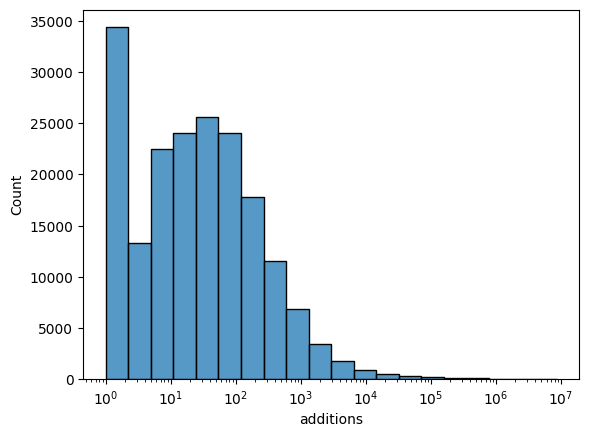

In [ ]:
# additions_hist, additions_edges = np.histogram(all_pr_df["additions"], bins=20)
sns.histplot(
    all_pr_df["additions"],  # type: ignore
    bins=20,
    log_scale=True,
)
plt.show()

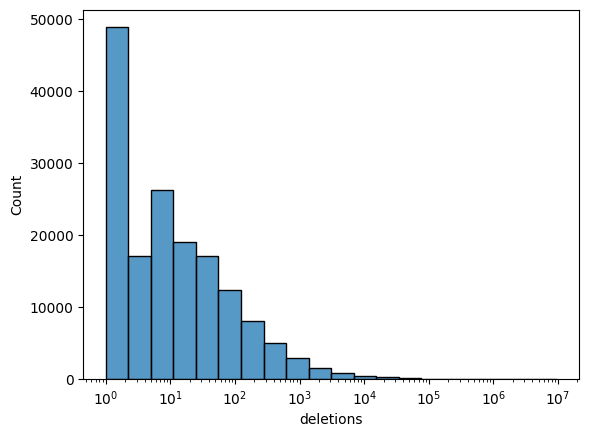

In [ ]:
# deletions_hist, deletions_edges = np.histogram(all_pr_df["deletions"], bins=20)
sns.histplot(
    all_pr_df["deletions"],  # type: ignore
    bins=20,
    log_scale=True,
)
plt.show()

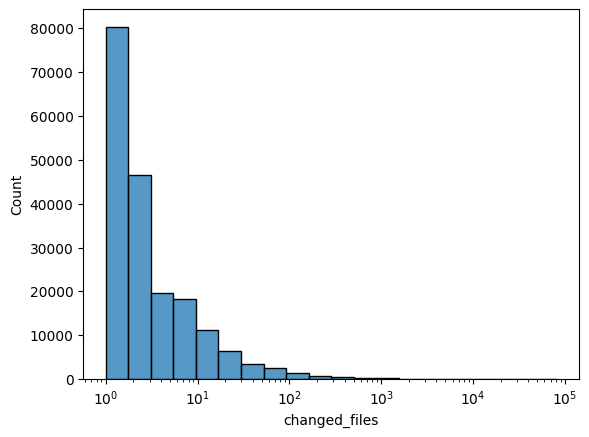

In [ ]:
# changed_files_hist, changed_files_edges = np.histogram(
#     all_pr_df["changed_files"], bins=20
# )
sns.histplot(
    all_pr_df["changed_files"],  # type: ignore
    bins=20,
    log_scale=True,
)
plt.show()

## Basic (Temporal)

In [ ]:
weekly_grouper = pd.Grouper(key="created_at", freq="W")  # Monday-Sunday
monthly_grouper = pd.Grouper(key="created_at", freq="ME")

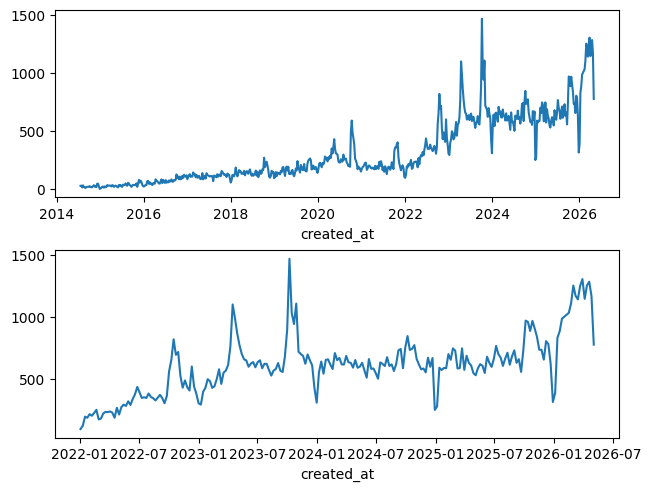

In [ ]:
plt.figure(layout="constrained")

plt.subplot(2, 1, 1)
sns.lineplot(all_pr_df.groupby(weekly_grouper).size())

# Since 2022:
plt.subplot(2, 1, 2)
sns.lineplot(
    all_pr_df.groupby(weekly_grouper).size()[datetime(2022, 1, 1, tzinfo=UTC) :]
)

plt.show()

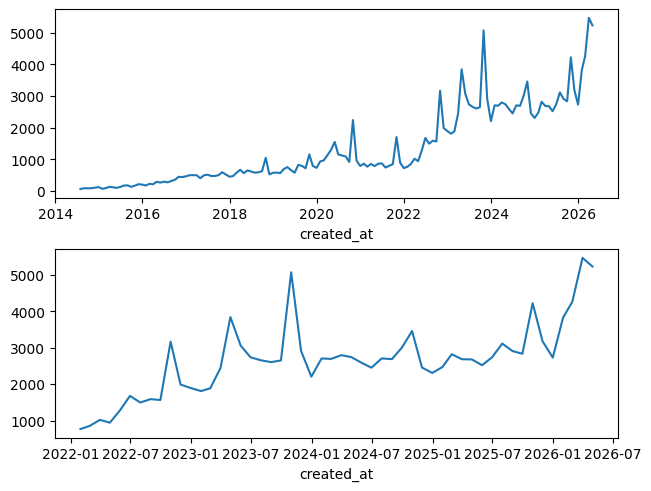

In [ ]:
plt.figure(layout="constrained")

plt.subplot(2, 1, 1)
sns.lineplot(all_pr_df.groupby(monthly_grouper).size())

# Since 2022:
plt.subplot(2, 1, 2)
sns.lineplot(
    all_pr_df.groupby(monthly_grouper).size()[datetime(2022, 1, 1, tzinfo=UTC) :]
)

plt.show()

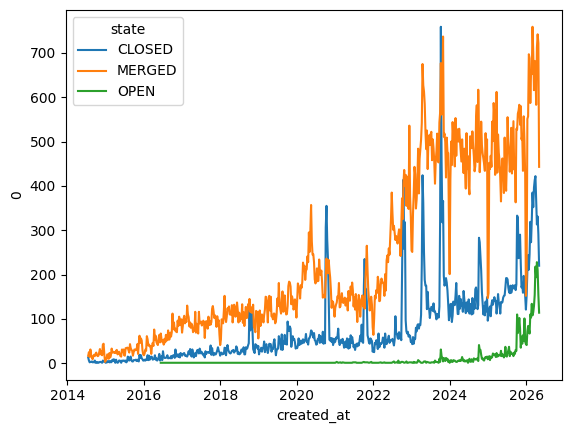

In [ ]:
sns.lineplot(
    all_pr_df.groupby(["state", weekly_grouper], observed=True).size().reset_index(),
    x="created_at",
    y=0,
    hue="state",
)
plt.show()

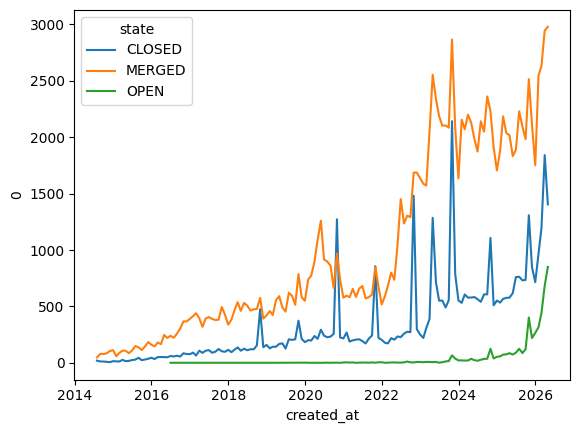

In [ ]:
sns.lineplot(
    all_pr_df.groupby(["state", monthly_grouper], observed=True).size().reset_index(),
    x="created_at",
    y=0,
    hue="state",
)
plt.show()

## LLM Agent Classification/Detection

In [ ]:
import re

AGENT_AUTHOR_INDICATORS = [
    *["copilot", "swe-agent"],
    *["cursor", "cursoragent", "codeium", "tabnine", "claude", "gpt", "openai"],
]
AGENT_AUTHOR_PATTERN = "|".join(map(re.escape, AGENT_AUTHOR_INDICATORS))
AGENT_BRANCH_PATTERN = "(agents|copilot)/"

# Check PR commit authors.
commit_authors = all_timeline_item_df["commit.authors.nodes"].explode()

authors_email = commit_authors.str.get("email")  # type: ignore
authors_name = commit_authors.str.get("name")  # type: ignore

authors_email_match = authors_email.str.contains(AGENT_AUTHOR_PATTERN, case=False)
authors_name_match = authors_name.str.contains(AGENT_AUTHOR_PATTERN, case=False)

authors_match = authors_email_match | authors_name_match

# Git commits may have multiple (co-)authors. We consider a commit to be
# agent-generated iff any "authors" are LLM agents.
all_timeline_item_df["agent_generated"] = authors_match.groupby(
    authors_match.index, sort=False
).any()

# Similarly, a PR on GitHub may have multiple commits; we consider a PR to be
# agent-generated if any commits are agent-generated.
pr_has_agent_commit = (
    all_timeline_item_df.groupby("pr_index", sort=False)["agent_generated"]
    .any()
    # NOTE: `reindex` is only needed if there are PRs that don't have any items.
    .reindex(index=all_pr_df.index, fill_value=False)
)

# pr_has_agent_commit = (
#     pd.merge(
#         all_pr_df.index.to_series(name="index"),
#         # all_timeline_item_df[["pr_index", "agent_generated"]],
#         all_timeline_item_df["agent_generated"],
#         how="left",
#         left_on="index",
#         # right_on="pr_index",
#         right_on=all_timeline_item_df["pr_index"],
#         validate="one_to_many",
#     )
#     .groupby("index", sort=False)["agent_generated"]
#     .any()
# )

# Check each PR's branch.
pr_branch_match = all_pr_df["head_ref_name"].str.match(AGENT_BRANCH_PATTERN, case=False)

all_pr_df["agent_generated"] = pr_has_agent_commit | pr_branch_match

In [ ]:
all_pr_df["agent_generated"].value_counts()

,count
agent_generated,
False,190263
True,8476


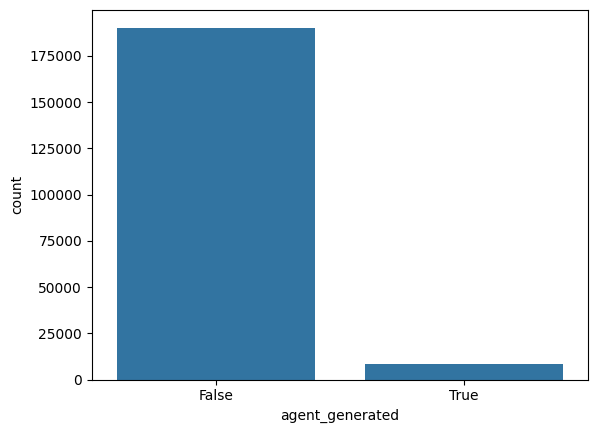

In [ ]:
sns.barplot(all_pr_df["agent_generated"].value_counts())
plt.show()

In [ ]:
all_pr_df.groupby("repo_full_name")["agent_generated"].value_counts().unstack()

agent_generated,False,True
repo_full_name,,
Genymobile/scrcpy,864,4
Significant-Gravitas/AutoGPT,5665,2383
TheAlgorithms/Python,12907,15
ant-design/ant-design,22278,317
langchain-ai/langchain,22677,295
microsoft/PowerToys,7871,399
microsoft/TypeScript,19366,93
microsoft/vscode,53882,4185
open-webui/open-webui,7875,369


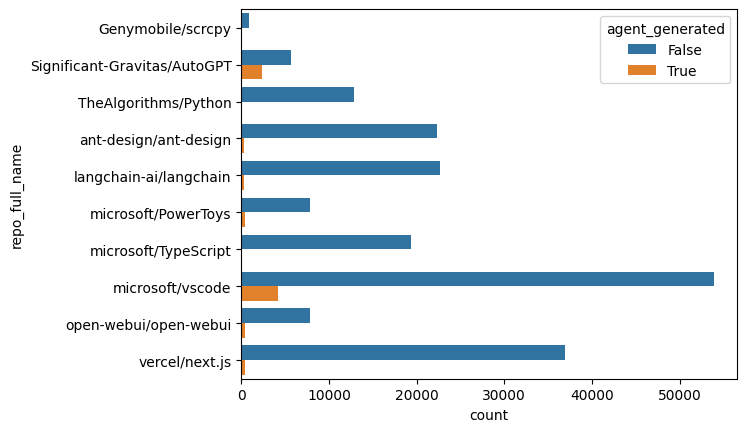

In [ ]:
sns.barplot(
    all_pr_df.groupby("repo_full_name")["agent_generated"].value_counts().reset_index(),
    x="count",
    y="repo_full_name",
    hue="agent_generated",
    orient="h",
)
plt.show()

In [ ]:
# https://github.com/trent-b/iterative-stratification
%pip install --only-binary=':all:' 'iterative-stratification==0.1.9'

In [ ]:
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from numpy.random import PCG64, Generator
from sklearn.model_selection import train_test_split

SAMPLE_SIZE = 200
rng = Generator(PCG64(seed=42))


def div_exact(x: int, y: int, /) -> int:
    (quotient, remainder) = divmod(x, y)
    assert remainder == 0
    return quotient


# Restrict the dataset to five (randomly selected) repositories.
repos_selected = rng.choice(all_pr_df["repo_full_name"].unique(), size=5, replace=False)
pr_selected_df = all_pr_df[all_pr_df["repo_full_name"].isin(repos_selected)]

# Unstratified:
# verification_sample_df = pr_selected_df.sample(n=SAMPLE_SIZE, random_state=rng)

# Stratified (equal allocation):
# verification_sample_df = pr_selected_df.groupby("repo_full_name").sample(
#     n=div_exact(SAMPLE_SIZE, len(repos_selected)), random_state=rng
# )

# Stratified (proportional allocation):

# The length of the returned data frame may not equal `SAMPLE_SIZE`.
# verification_sample_df = pr_selected_df.groupby("repo_full_name").sample(
#     frac=SAMPLE_SIZE / len(pr_selected_df), random_state=rng
# )

# This internally uses `StratifiedShuffleSplit`.
# Complaints:
# 1. Why is there no function for stratified sampling w/o splitting?
# 2. This doesn't support `numpy.random.Generator`.
# [_, verification_sample_df] = train_test_split(
#     pr_selected_df,
#     test_size=SAMPLE_SIZE,
#     random_state=42,
#     shuffle=True,
#     stratify=pr_selected_df["repo_full_name"],
# )

# Stratified (proportional allocation, multi-label):
msss = MultilabelStratifiedShuffleSplit(test_size=SAMPLE_SIZE, random_state=42)
(_, test_index) = next(
    msss.split(
        pr_selected_df,
        pd.get_dummies(pr_selected_df[["repo_full_name", "agent_generated"]]),
    )
)
verification_sample_df = pr_selected_df.iloc[test_index]

# Annoying:
assert len(verification_sample_df) == SAMPLE_SIZE + 1
verification_sample_df = verification_sample_df.head(n=SAMPLE_SIZE)

verification_sample_df[
    ["repo_full_name", "created_at", "closed_at", "head_ref_name", "permalink"]
    + ["agent_generated"]
].to_csv("verification_sample_strict.csv", index=False)

## GHAgentFiles

In [ ]:
import gzip

import pandas as pd

with gzip.open("all_metadata.csv.gz") as file:
    gh_all_metadata_df = pd.read_csv(file)  # type: ignore

git_change_type = pd.CategoricalDtype(["A", "D", "M", "R", "T"])
agent_name_type = pd.CategoricalDtype(
    ["claude", "codex", "copilot", "cursor", "gemini", "windsurf"] + ["generic"]
)
category_type = pd.CategoricalDtype(["context", "skills", "subagents"])

gh_all_metadata_df["commit_date"] = pd.to_datetime(gh_all_metadata_df["commit_date"], utc=True, unit="s")
gh_all_metadata_df["authored_date"] = pd.to_datetime(gh_all_metadata_df["authored_date"], utc=True, unit="s")
gh_all_metadata_df["git_change_type"] = gh_all_metadata_df["git_change_type"].astype(git_change_type)
assert gh_all_metadata_df["git_change_type"].notna().all()
gh_all_metadata_df["agent_name"] = gh_all_metadata_df["agent_name"].astype(agent_name_type)
assert gh_all_metadata_df["agent_name"].notna().all()
gh_all_metadata_df["category"] = gh_all_metadata_df["category"].astype(category_type)
assert gh_all_metadata_df["category"].notna().all()

In [ ]:
with gzip.open("repositories.csv.gz") as file:
    gh_repo_df = pd.read_csv(file)  # type: ignore

# The `dtype` parameter must be capitalized due to the presence of missing values. See:
# https://pandas.pydata.org/pandas-docs/version/2.2/user_guide/integer_na.html
gh_repo_df["contributors"] = gh_repo_df["contributors"].astype("Int64")
gh_repo_df["createdAt"] = pd.to_datetime(gh_repo_df["createdAt"], utc=True, format="ISO8601")
gh_repo_df["pushedAt"] = pd.to_datetime(gh_repo_df["pushedAt"], utc=True, format="ISO8601")
gh_repo_df["updatedAt"] = pd.to_datetime(gh_repo_df["updatedAt"], utc=True, format="ISO8601")
gh_repo_df["blankLines"] = gh_repo_df["blankLines"].astype("Int64")
gh_repo_df["codeLines"] = gh_repo_df["codeLines"].astype("Int64")
gh_repo_df["commentLines"] = gh_repo_df["commentLines"].astype("Int64")
gh_repo_df["lastCommit"] = pd.to_datetime(gh_repo_df["lastCommit"], utc=True, format="ISO8601")

In [ ]:
gh_all_metadata_df.head()

,repository,commit_hash,author_name,author_email,committer_name,committer_email,commit_date,authored_date,file_path,previous_file_path,file_hash,previous_file_hash,git_change_type,relative_commit_order,uid,agent_name,category,symbolic_link,previous_symbolic_link
0,sparklemotion/nokogiri,b0881a2bcd04c85a86a27314591366cb6c7fb8f9,Mike Dalessio,mike.dalessio@gmail.com,Mike Dalessio,mike.dalessio@gmail.com,2026-06-14 21:45:28+00:00,2026-06-14 21:44:04+00:00,AGENTS.md,NaN,c24b262bbf0082de42e70be04baaa3ab7c7261e3d72563...,NaN,A,0,sparklemotion/nokogiri/AGENTS.md/b0881a2bcd04c...,generic,context,False,False
1,connectbot/connectbot,57b911768f514792030435479a1f579ebc53a261,Kenny Root,kenny@the-b.org,Kenny Root,kenny@the-b.org,2026-05-06 03:33:50+00:00,2026-05-06 02:56:37+00:00,AGENTS.md,AGENTS.md,6e2e8776fe96ae33bf29d07a51fd1f8780325eb73ce49d...,00c03145edf129d71ecae5227a6c4d42de1f143fc6b325...,M,0,connectbot/connectbot/AGENTS.md/e18e800aefa9aa...,generic,context,False,False
2,connectbot/connectbot,e18e800aefa9aa4113f4588b795dbc5a6075adf2,Kenny Root,kenny@the-b.org,Kenny Root,kenny@the-b.org,2026-05-01 04:37:36+00:00,2026-05-05 12:12:15+00:00,AGENTS.md,NaN,00c03145edf129d71ecae5227a6c4d42de1f143fc6b325...,NaN,A,1,connectbot/connectbot/AGENTS.md/e18e800aefa9aa...,generic,context,False,False
3,nodebox/nodebox,773a208dc1a024afd40edd0d64be39fbf17db49d,Frederik De Bleser,frederik@debleser.be,Frederik De Bleser,frederik@debleser.be,2026-02-02 11:55:12+00:00,2026-02-02 11:55:12+00:00,AGENTS.md,AGENTS.md,deb7761bee27ce24759f6e599be29bf36be551c88f754e...,834c20b068eb05f0b221b525261c2ffc5cad2f8b91cd70...,M,0,nodebox/nodebox/AGENTS.md/5ed79e8cbe548ac10adb...,generic,context,False,False
4,nodebox/nodebox,0728984405bc45b5de621fa61063dc2c9e289395,Frederik De Bleser,frederik@debleser.be,GitHub,noreply@github.com,2026-02-02 11:52:47+00:00,2026-02-02 11:52:47+00:00,AGENTS.md,AGENTS.md,834c20b068eb05f0b221b525261c2ffc5cad2f8b91cd70...,deb7761bee27ce24759f6e599be29bf36be551c88f754e...,M,1,nodebox/nodebox/AGENTS.md/5ed79e8cbe548ac10adb...,generic,context,False,False


In [ ]:
gh_repo_df.head()

,id,name,isFork,commits,branches,releases,forks,mainLanguage,defaultBranch,license,...,metrics,lastCommit,lastCommitSHA,hasWiki,isArchived,isDisabled,isLocked,languages,labels,topics
0,0,sparklemotion/nokogiri,False,8016,51,90,940,C,main,MIT License,...,"[{""blankLines"":0,""codeLines"":84,""commentLines""...",2026-06-27 12:39:57+00:00,00dd9babd590bcc877d358c1e4246ae563311855,True,False,False,False,"{""C"":1487173,""Ruby"":1338477,""Java"":666858,""C++...",backport;blocked;dependencies;event/hackday202...,libxml2;libxslt;nokogiri;ruby;ruby-gem;sax;xer...
1,61,davidb/scala-maven-plugin,False,1293,3,0,158,Java,master,The Unlicense,...,"[{""blankLines"":0,""codeLines"":5,""commentLines"":...",2026-06-23 06:04:27+00:00,e80bb89583e425f5c81c66e9acfc538127e1685a,True,False,False,False,"{""Java"":230106,""CSS"":8764,""Groovy"":6864,""Scala...",2.12-release;2.13-release;2.14-release;bug;dep...,NaN
2,82,tcurdt/jdeb,False,1277,3,0,311,Java,master,Apache License 2.0,...,"[{""blankLines"":1804,""codeLines"":6417,""commentL...",2026-06-24 01:09:14+00:00,0d24cc19453fa89a5512e9d1287ee248388bca7f,False,False,False,False,"{""Java"":366823,""Shell"":5002,""Groovy"":2690,""Pow...",bug;dependencies;github_actions;good first iss...,ant-task;cross-platform;deb;debian-packages;ja...
3,101,mth/yeti,False,2987,2,0,16,Java,master,Other,...,"[{""blankLines"":23,""codeLines"":313,""commentLine...",2025-12-18 07:56:49+00:00,4d7916b36a1303b6b88edea9e80c8319bbbe9c02,False,False,False,False,"{""Java"":847059,""Vim Script"":11117,""Emacs Lisp""...",NaN,NaN
4,165,tcurdt/jdependency,False,691,2,4,29,Java,master,Apache License 2.0,...,"[{""blankLines"":26,""codeLines"":632,""commentLine...",2026-06-24 01:09:32+00:00,6fe636e842aeaffed4223c3d34d268481e3b784a,False,False,False,False,"{""Java"":69217,""Shell"":321}",bug;dependencies;github_actions;improvement;java,dependencies;dependency-analysis;jarjar;java;p...


In [ ]:
# The TypeScript repository might be exceptional because the TypeScript team
# has been porting the TypeScript compiler to Go throughout 2025 and 2026.
# Importantly, development is occurring in a separate repository.
# EXAMPLE_REPO = "microsoft/TypeScript"
EXAMPLE_REPO = "vercel/next.js"

In [ ]:
gh_repo_df[gh_repo_df["name"].str.fullmatch(EXAMPLE_REPO, case=False)]

,id,name,isFork,commits,branches,releases,forks,mainLanguage,defaultBranch,license,...,metrics,lastCommit,lastCommitSHA,hasWiki,isArchived,isDisabled,isLocked,languages,labels,topics
38944,7819428,vercel/next.js,False,34421,2043,1000,31237,JavaScript,canary,MIT License,...,"[{""blankLines"":29,""codeLines"":114789,""commentL...",2026-06-20 11:40:12+00:00,79142d7806ff4194c8d9885b80fa69db5ecf534a,False,False,False,False,"{""JavaScript"":38166754,""TypeScript"":22956829,""...",CI Bypass Graphite Optimization;Cache Componen...,blog;browser;compiler;components;hybrid;nextjs...


In [ ]:
repo_example_metadata_df = gh_all_metadata_df[
    gh_all_metadata_df["repository"].str.fullmatch(EXAMPLE_REPO, case=False)
]
assert (repo_example_metadata_df["git_change_type"] != "D").all()
agent_files_introduced_at = repo_example_metadata_df["commit_date"].min()
print(agent_files_introduced_at)

2026-01-05 12:32:27+00:00


In [ ]:
monthly_grouper = pd.Grouper(key="created_at", freq="ME")

(
    pr_df_map[EXAMPLE_REPO]
    .pipe(lambda df: df[df["created_at"] < agent_files_introduced_at])
    .pipe(lambda df: df.groupby(monthly_grouper).size())
    .describe()
)

,0
count,112.000000
mean,301.553571
std,203.761954
min,32.000000
25%,133.500000
50%,243.000000
75%,451.250000
max,881.000000


In [ ]:
(
    pr_df_map[EXAMPLE_REPO]
    .pipe(lambda df: df[agent_files_introduced_at <= df["created_at"]])
    .pipe(lambda df: df.groupby(monthly_grouper).size())
    .describe()
)

,0
count,4.000000
mean,707.500000
std,70.985914
min,626.000000
25%,659.750000
50%,714.000000
75%,761.750000
max,776.000000


Note that we only have data for 5 months after the introduction of agent configuration files.

In [ ]:
(
    pr_df_map[EXAMPLE_REPO]
    .pipe(lambda df: df[df["created_at"] < agent_files_introduced_at])
    .pipe(lambda df: df["additions"] + df["deletions"])
    .describe()
)

,0
count,3.377400e+04
mean,1.239243e+03
std,2.426416e+04
min,0.000000e+00
25%,7.000000e+00
50%,4.100000e+01
75%,1.640000e+02
max,2.238384e+06


In [ ]:
(
    pr_df_map[EXAMPLE_REPO]
    .pipe(lambda df: df[agent_files_introduced_at <= df["created_at"]])
    .pipe(lambda df: df["additions"] + df["deletions"])
    .describe()
)

,0
count,2.830000e+03
mean,4.796579e+03
std,1.083342e+05
min,0.000000e+00
25%,2.200000e+01
50%,9.800000e+01
75%,3.447500e+02
max,3.078456e+06
